# import libraries 

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load Dataset

In [ ]:
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv", delimiter=',')

#Pandas operations
print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
print("Null values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


df:                  Job_Title  Average_Salary  Years_Experience Education_Level  \
0          Security Guard           45795                28        Master's   
1      Research Scientist          133355                20             PhD   
2     Construction Worker          146216                 2     High School   
3       Software Engineer          136530                13             PhD   
4       Financial Analyst           70397                22     High School   
...                   ...             ...               ...             ...   
2995               Doctor          111319                 6      Bachelor's   
2996        UX Researcher           44363                29             PhD   
2997       Data Scientist           61325                23        Master's   
2998     Graphic Designer          110296                 7             PhD   
2999     Graphic Designer          123909                25             PhD   

      AI_Exposure_Index  Tech_Growth_Factor  A

# Seaborn Graphs

['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Automation_Probability_2030', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10', 'Risk_Category_encoded']


C:\Users\Hp\AppData\Local\Temp\ipykernel_2268\952063590.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Category_encoded', data=df,


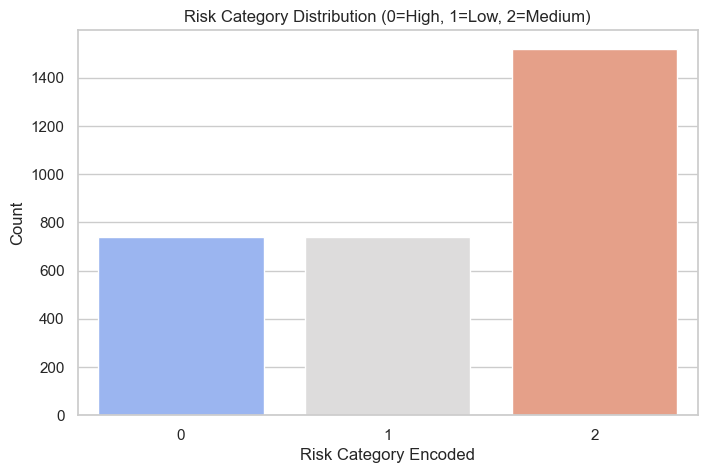

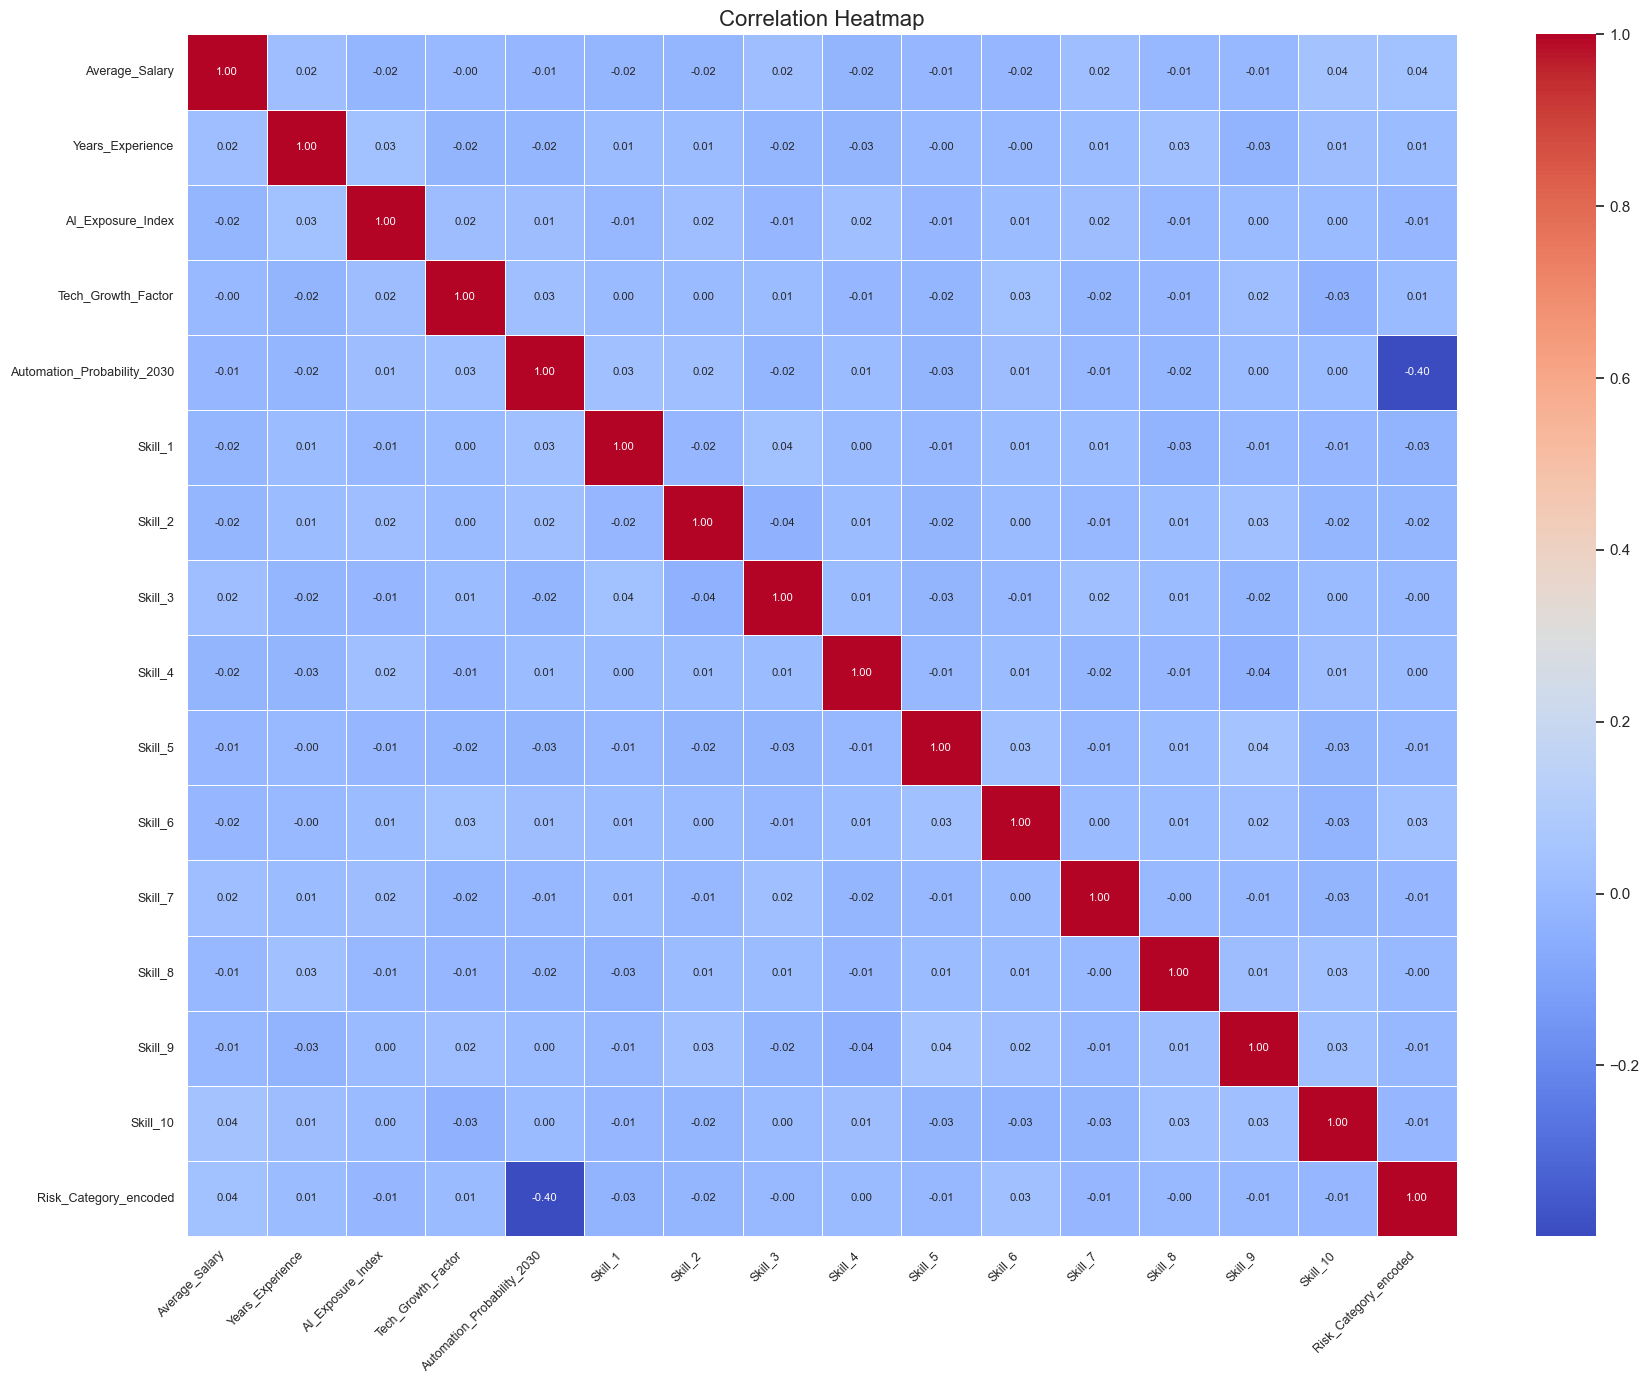

C:\Users\Hp\AppData\Local\Temp\ipykernel_2268\952063590.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Category_encoded', y=var, data=df,


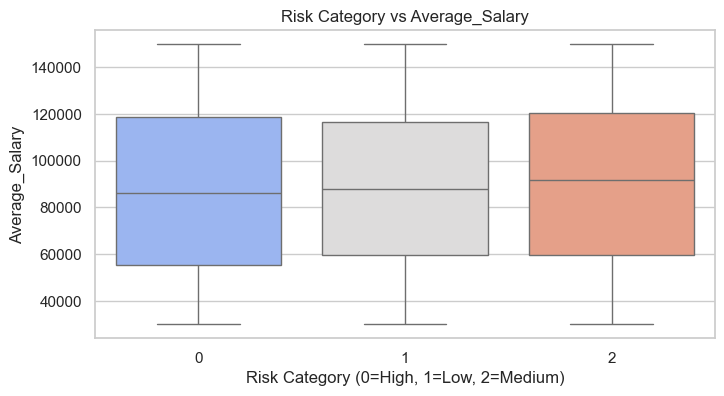

C:\Users\Hp\AppData\Local\Temp\ipykernel_2268\952063590.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Category_encoded', y=var, data=df,


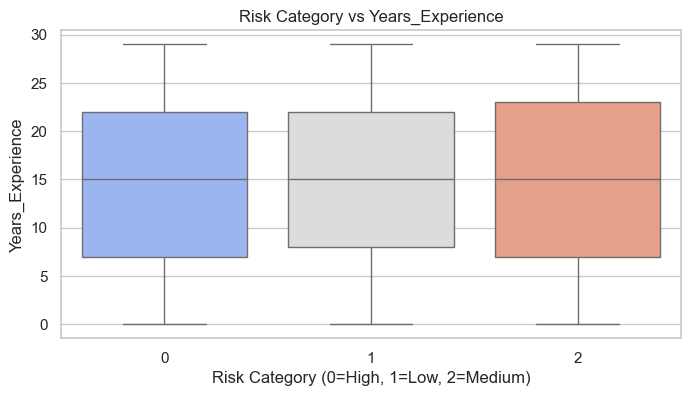

C:\Users\Hp\AppData\Local\Temp\ipykernel_2268\952063590.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Category_encoded', y=var, data=df,


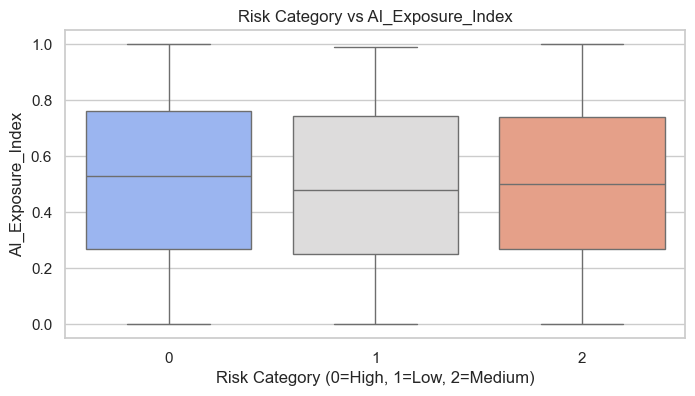

C:\Users\Hp\AppData\Local\Temp\ipykernel_2268\952063590.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Category_encoded', y=var, data=df,


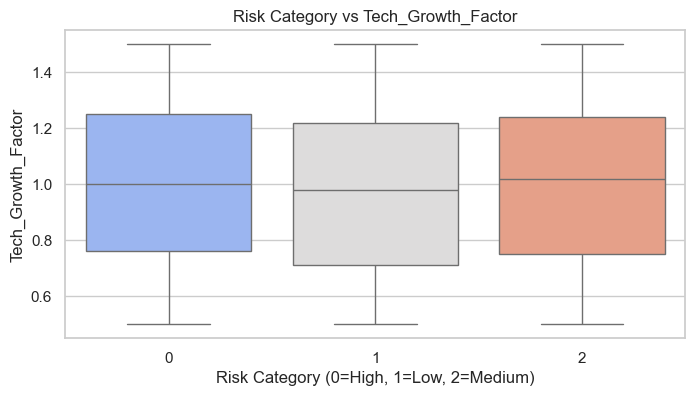

C:\Users\Hp\AppData\Local\Temp\ipykernel_2268\952063590.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Category_encoded', y=var, data=df,


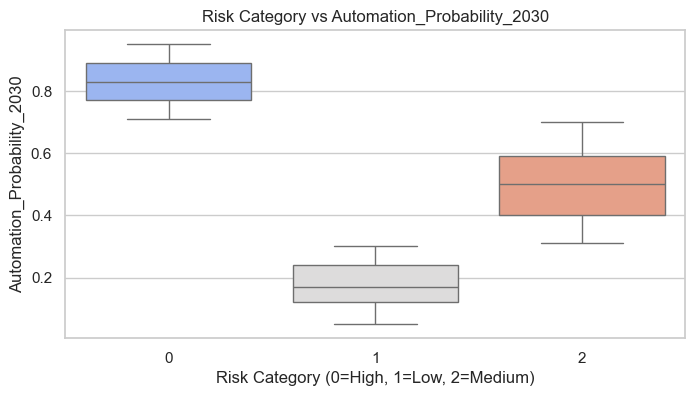

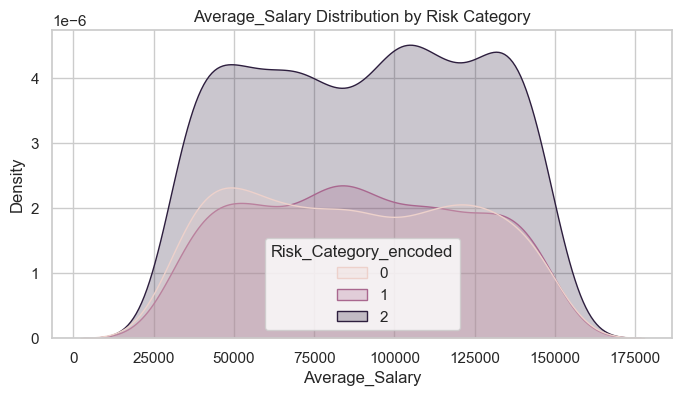

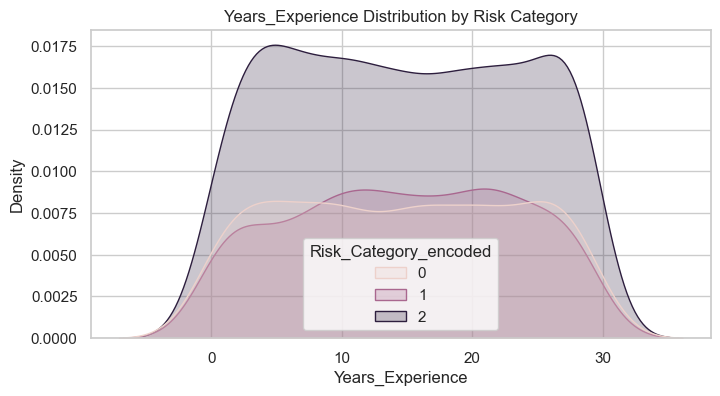

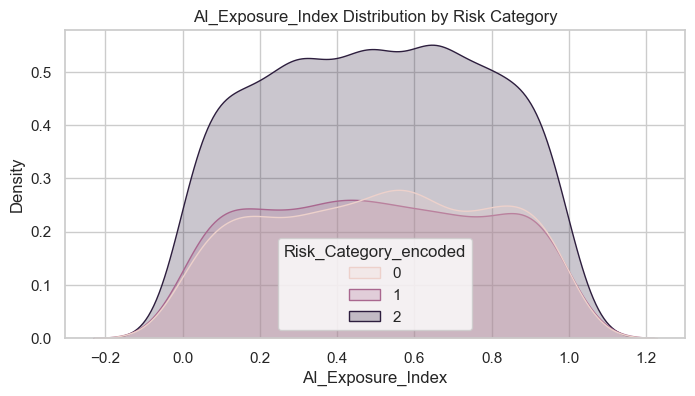

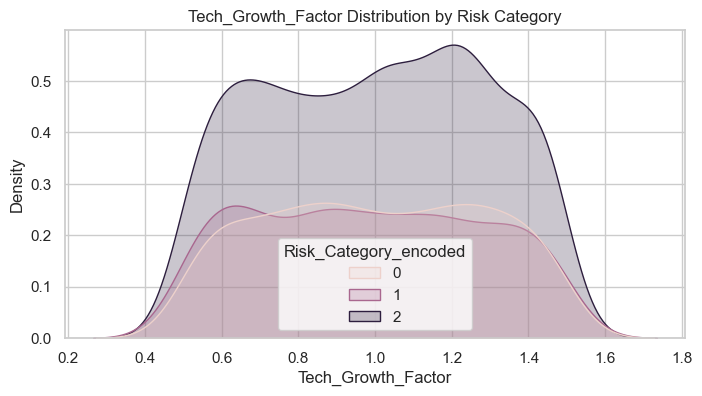

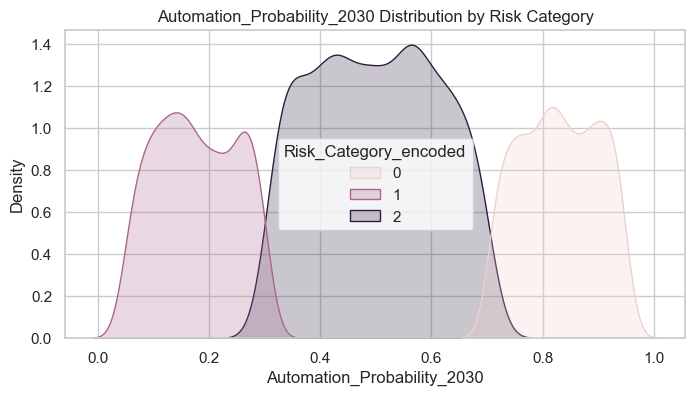

In [ ]:
print(df.columns.tolist())  

# Countplot
plt.figure(figsize=(8,5))
sns.countplot(x='Risk_Category_encoded', data=df,
              palette='coolwarm')
plt.title("Risk Category Distribution (0=High, 1=Low, 2=Medium)")
plt.xlabel("Risk Category Encoded")
plt.ylabel("Count")
plt.show()

# Heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True),
            annot=True, fmt=".2f", cmap='coolwarm',
            annot_kws={"size": 8},
            linewidths=0.5, linecolor='white')
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

# Boxplot — x=Risk_Category_encoded (categorical), y=feature
variables = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index',
             'Tech_Growth_Factor', 'Automation_Probability_2030']

for var in variables:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Risk_Category_encoded', y=var, data=df,
                palette='coolwarm')
    plt.title(f"Risk Category vs {var}")
    plt.xlabel("Risk Category (0=High, 1=Low, 2=Medium)")
    plt.ylabel(var)
    plt.show()

# 4. KDE Plot
for var in variables:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=var,
                hue='Risk_Category_encoded', fill=True)
    plt.title(f"{var} Distribution by Risk Category")
    plt.show()

# Version 1 of Classification
# X = 4 numeric features (AI_Exposure_Index,Tech_Growth_Factor,Average_Salary,Years_Experience)
# y = Risk_Category_encoded (0=High, 1=Low, 2=Medium)

# Train Test Split Function

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

X = df[['AI_Exposure_Index', 'Tech_Growth_Factor',
        'Average_Salary', 'Years_Experience']]

y = df['Risk_Category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# LOGISTIC REGRESSION

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n" + "=" * 50)
print("V1 — LOGISTIC REGRESSION")
print("=" * 50)
results_lr = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
print("Actual vs Predicted:\n", results_lr)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_lr, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

#  KNN CLASSIFIER
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\n" + "=" * 50)
print("V1 — KNN CLASSIFIER")
print("=" * 50)
results_knn = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_knn})
print("Actual vs Predicted:\n", results_knn)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_knn)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_knn, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_knn, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_knn, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))


#  DECISION TREE CLASSIFIER
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\n" + "=" * 50)
print("V1 — DECISION TREE CLASSIFIER")
print("=" * 50)
results_dt = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_dt})
print("Actual vs Predicted:\n", results_dt)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_dt)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_dt, average="weighted"):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

X_train shape: (2400, 4)
X_test shape : (600, 4)

V1 — LOGISTIC REGRESSION
Actual vs Predicted:
       Actual  Predicted
1801       2          2
1190       0          2
1817       2          2
251        2          2
2505       2          2
...      ...        ...
104        2          2
2087       1          2
599        2          2
1756       2          2
1323       0          2

[600 rows x 2 columns]
Accuracy  : 47.33%
Precision : 0.2240
Recall    : 0.4733
F1 Score  : 0.3041
Confusion Matrix:
 [[  0   0 167]
 [  0   0 149]
 [  0   0 284]]


c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       167
           1       0.00      0.00      0.00       149
           2       0.47      1.00      0.64       284

    accuracy                           0.47       600
   macro avg       0.16      0.33      0.21       600
weighted avg       0.22      0.47      0.30       600


V1 — KNN CLASSIFIER
Actual vs Predicted:
       Actual  Predicted
1801       2          2
1190       0          1
1817       2          2
251        2          2
2505       2          2
...      ...        ...
104        2          2
2087       1          1
599        2          1
1756       2          1
1323       0          2

[600 rows x 2 columns]
Accuracy  : 33.33%
Precision : 0.3205
Recall    : 0.3333
F1 Score  : 0.3261
Confusion Matrix:
 [[ 50  34  83]
 [ 47  16  86]
 [ 84  66 134]]
Classification Report:
               precision    recall  f1-score   support

           0       0

# Version 1  Classification Results:
# Logistic Regression: 47.33% — predicted only class 2 (majority class)
# KNN: 33.33% — equivalent to random guessing (1/3 chance)
# Decision Tree: 37.33% — slightly better than random
# Low accuracy because 4 numeric features have near-zero correlation with Risk_Category 
